In [61]:
# GAURAV CHAUHAN
# E23CSEU0554


!pip install -q pandas numpy matplotlib seaborn scipy scikit-learn
!pip install -q nltk pillow opencv-python wfdb scikit-image

In [5]:
import os
import re
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from PIL import Image
import cv2

import wfdb
from skimage.feature import hog

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

file_name = "pima-indians-diabetes.csv"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)

print("Dataset downloaded")

Dataset downloaded


In [7]:
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    file_name,
    header=None,
    names=columns
)

print("Shape:", df.shape)

display(df.head())

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

Missing values:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Duplicate rows: 0


In [11]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in medical_columns:
    df[column] = df[column].replace(0, np.nan)

display(df.isnull().sum())

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
for column in medical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Remaining missing values:")
display(df.isnull().sum())

Remaining missing values:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [13]:
for column in medical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Remaining missing values:")
display(df.isnull().sum())

Remaining missing values:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


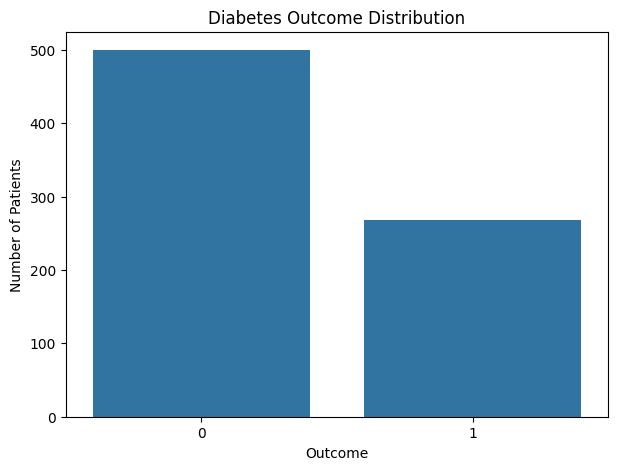

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Outcome"
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

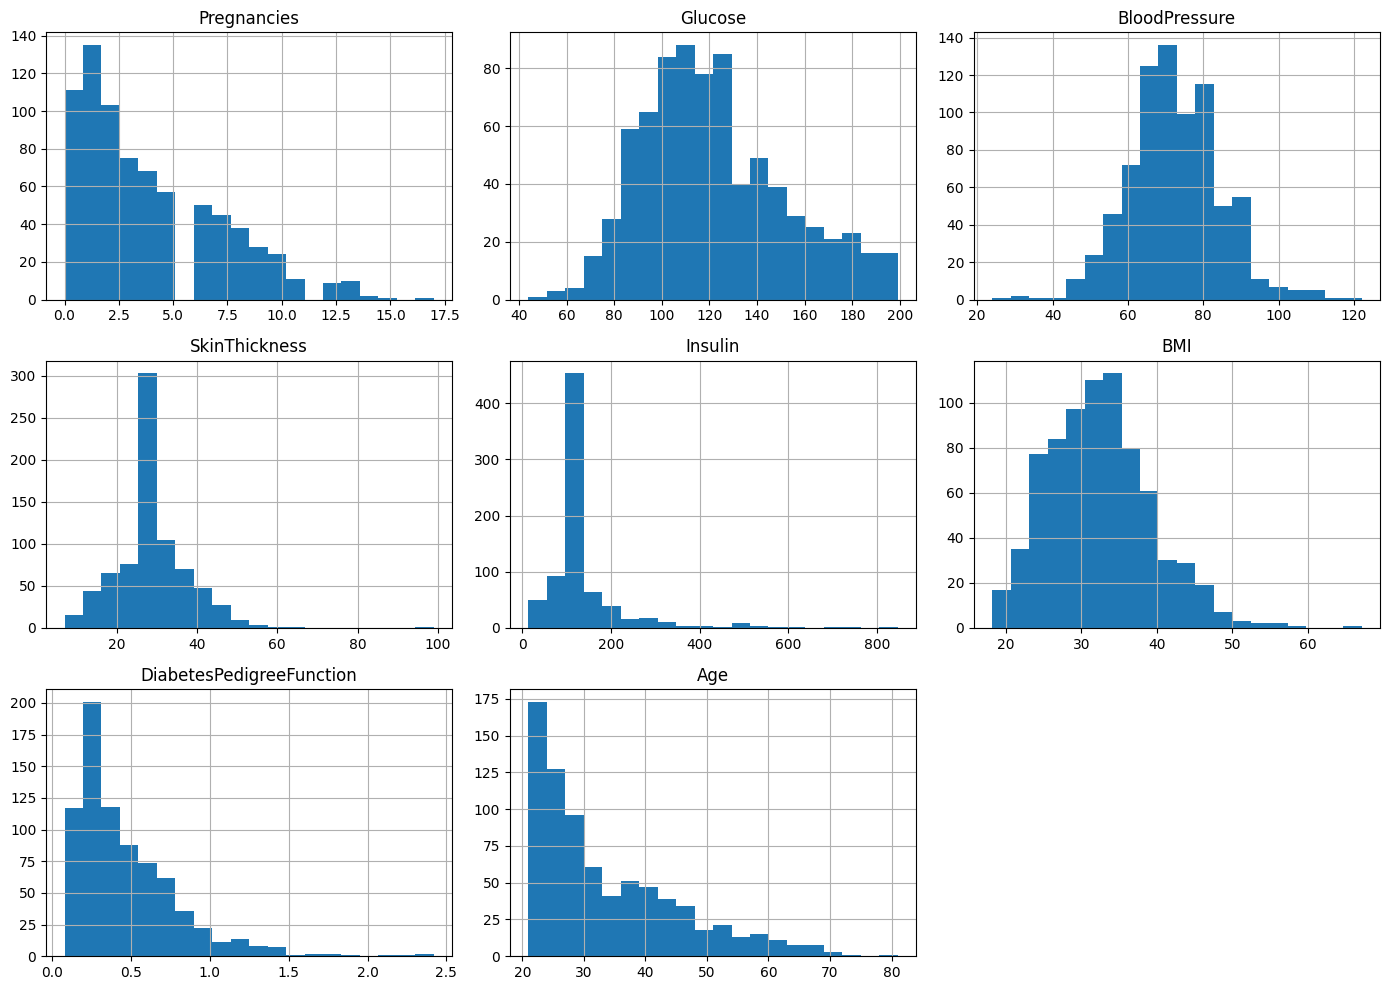

In [15]:
df[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
].hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

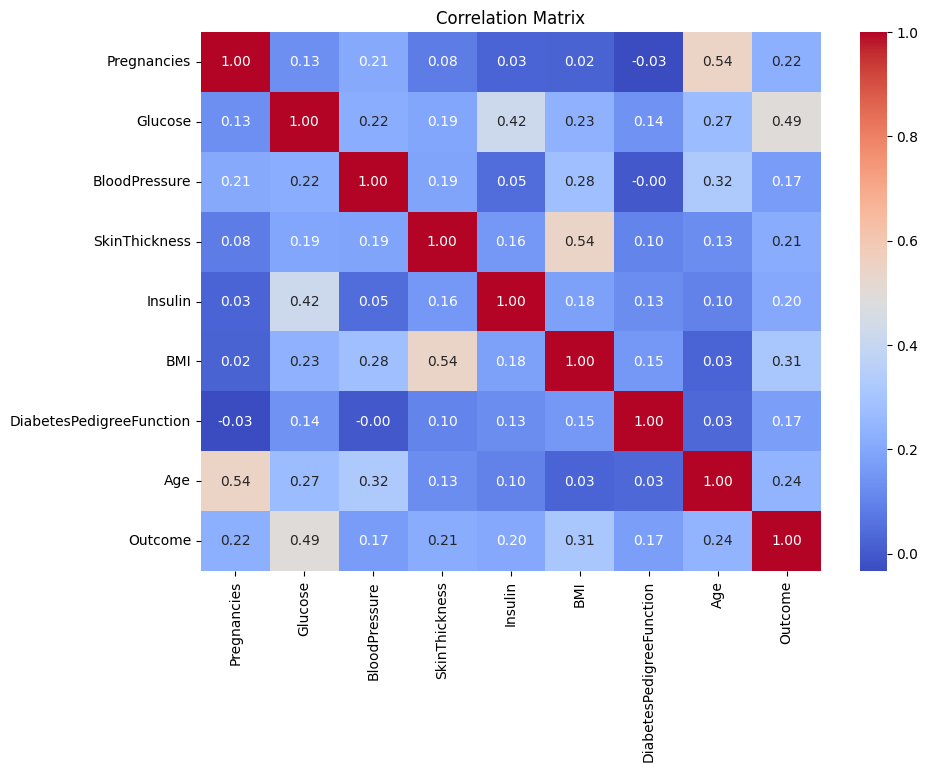

In [16]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [17]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"


def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Middle"
    else:
        return "Older"


df["BMI_Category"] = df["BMI"].apply(bmi_category)
df["Age_Group"] = df["Age"].apply(age_group)

display(
    df[
        ["BMI", "BMI_Category", "Age", "Age_Group"]
    ].head()
)

,BMI,BMI_Category,Age,Age_Group
0,33.6,Obese,50,Older
1,26.6,Overweight,31,Middle
2,23.3,Normal,32,Middle
3,28.1,Overweight,21,Young
4,43.1,Obese,33,Middle


In [18]:
diabetic = df[
    df["Outcome"] == 1
]["Glucose"]

non_diabetic = df[
    df["Outcome"] == 0
]["Glucose"]

t_stat, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

T-statistic: 14.852653441079662
P-value: 3.5421485614431447e-41
Reject H0


In [19]:
table = pd.crosstab(
    df["BMI_Category"],
    df["Outcome"]
)

display(table)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(
    table
)

print("Chi-square:", chi2_stat)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Significant association")
else:
    print("No significant association")

Outcome,0,1
BMI_Category,,
Normal,95,7
Obese,262,221
Overweight,139,40
Underweight,4,0


Chi-square: 74.9084804674606
P-value: 3.790718167139003e-16
Degrees of freedom: 3
Significant association


In [20]:
groups = [
    df[df["BMI_Category"] == category]["Glucose"]
    for category in df["BMI_Category"].unique()
]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference")
else:
    print("No significant difference")

F-statistic: 12.346120454153612
P-value: 6.819691504808377e-08
Significant difference


In [21]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features]
y = df["Outcome"]

X_chi = X - X.min()

selector = SelectKBest(
    chi2,
    k=5
)

selector.fit(
    X_chi,
    y
)

selected_features = X.columns[
    selector.get_support()
]

print("Selected features:")
print(list(selected_features))

Selected features:
['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (614, 8)
Testing shape: (154, 8)


In [23]:
text_file = "mtsamples.csv"

if os.path.exists(text_file):
    text_df = pd.read_csv(text_file)
    print("Dataset loaded")
else:
    text_df = pd.DataFrame()
    print("mtsamples.csv not found")

mtsamples.csv not found


In [24]:
if not text_df.empty:
    print("Shape:", text_df.shape)
    print("\nColumns:")
    print(text_df.columns.tolist())

    display(text_df.head())

In [25]:
if not text_df.empty:
    display(text_df.isnull().sum())

In [26]:
if not text_df.empty:

    possible_columns = [
        "transcription",
        "text",
        "description",
        "medical_transcription"
    ]

    text_column = None

    for column in possible_columns:
        if column in text_df.columns:
            text_column = column
            break

    if text_column is None:

        object_columns = text_df.select_dtypes(
            include="object"
        ).columns

        text_column = object_columns[-1]

    print("Text column:", text_column)

In [27]:
stop_words = set(
    stopwords.words("english")
)

def clean_text(text):

    text = str(text)

    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"\b\d{10,}\b",
        " ",
        text
    )

    text = text.lower()

    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    tokens = word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)


if not text_df.empty:

    text_df["cleaned_text"] = (
        text_df[text_column]
        .fillna("")
        .apply(clean_text)
    )

    print("Cleaning completed")

In [28]:
if not text_df.empty:

    print("Original:")
    print(text_df[text_column].iloc[0])

    print("\nCleaned:")
    print(text_df["cleaned_text"].iloc[0])

In [29]:
if not text_df.empty:

    text_df["text_length"] = (
        text_df["cleaned_text"]
        .str.split()
        .str.len()
    )

    plt.figure(figsize=(9, 5))

    sns.histplot(
        text_df["text_length"],
        bins=30
    )

    plt.title("Medical Transcription Length")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")

    plt.show()

In [30]:
if not text_df.empty:

    possible_categories = [
        "medical_specialty",
        "medical specialty",
        "specialty",
        "category"
    ]

    category_column = None

    for column in possible_categories:
        if column in text_df.columns:
            category_column = column
            break

    if category_column:

        counts = (
            text_df[category_column]
            .value_counts()
            .head(15)
        )

        display(counts)

In [31]:
if not text_df.empty and category_column:

    counts = (
        text_df[category_column]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 6))

    counts.plot(kind="bar")

    plt.title("Top Medical Specialties")
    plt.xlabel("Specialty")
    plt.ylabel("Number of Records")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [32]:
if not text_df.empty:

    vectorizer = TfidfVectorizer(
        max_features=1000,
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )

    X_text = vectorizer.fit_transform(
        text_df["cleaned_text"]
    )

    print("TF-IDF shape:", X_text.shape)

In [33]:
if not text_df.empty:

    features = vectorizer.get_feature_names_out()

    print("First 30 features:")
    print(features[:30])

In [34]:
if not text_df.empty:

    if X_text.shape[0] >= 3:

        X_pca_input = X_text[:, :500].toarray()

        pca = PCA(
            n_components=2,
            random_state=42
        )

        X_pca = pca.fit_transform(
            X_pca_input
        )

        print(
            "Explained variance:",
            pca.explained_variance_ratio_
        )

In [35]:
if not text_df.empty and X_text.shape[0] >= 3:

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        alpha=0.5
    )

    plt.title("PCA of Medical Text")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.show()

In [36]:
def augment_text(text):

    words = text.split()

    if len(words) < 5:
        return text

    index = np.random.randint(
        0,
        len(words)
    )

    words.pop(index)

    return " ".join(words)


if not text_df.empty:

    text_df["augmented_text"] = (
        text_df["cleaned_text"]
        .head(10)
        .apply(augment_text)
    )

    display(
        text_df[
            [
                "cleaned_text",
                "augmented_text"
            ]
        ]
    )

In [37]:
image_path = Path("chest_xray")

train_path = image_path / "train"

normal_path = train_path / "NORMAL"
pneumonia_path = train_path / "PNEUMONIA"

In [38]:
def get_images(folder):

    if not folder.exists():
        return []

    images = []

    for extension in [
        "*.jpeg",
        "*.jpg",
        "*.png"
    ]:
        images.extend(
            folder.glob(extension)
        )

    return images


normal_images = get_images(
    normal_path
)

pneumonia_images = get_images(
    pneumonia_path
)

print(
    "Normal images:",
    len(normal_images)
)

print(
    "Pneumonia images:",
    len(pneumonia_images)
)

Normal images: 0
Pneumonia images: 0


In [39]:
image_summary = pd.DataFrame({
    "Class": [
        "NORMAL",
        "PNEUMONIA"
    ],
    "Count": [
        len(normal_images),
        len(pneumonia_images)
    ]
})

display(image_summary)

,Class,Count
0,NORMAL,0
1,PNEUMONIA,0


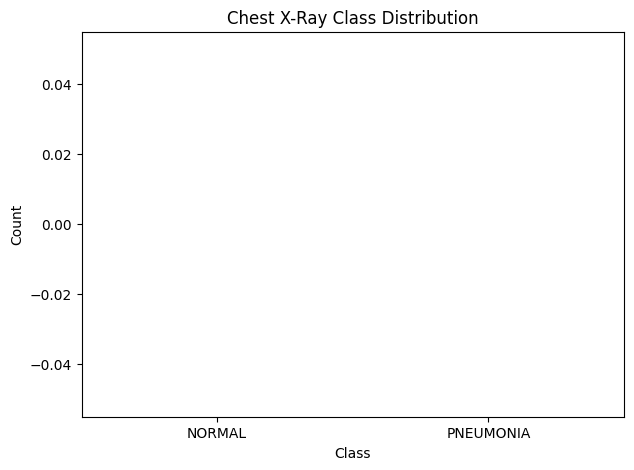

In [40]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=image_summary,
    x="Class",
    y="Count"
)

plt.title("Chest X-Ray Class Distribution")
plt.show()

In [41]:
if normal_images and pneumonia_images:

    normal_image = Image.open(
        normal_images[0]
    )

    pneumonia_image = Image.open(
        pneumonia_images[0]
    )

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(
        normal_image,
        cmap="gray"
    )

    plt.title("Normal")
    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(
        pneumonia_image,
        cmap="gray"
    )

    plt.title("Pneumonia")
    plt.axis("off")

    plt.show()

In [42]:
if normal_images and pneumonia_images:

    normal_image = Image.open(
        normal_images[0]
    )

    pneumonia_image = Image.open(
        pneumonia_images[0]
    )

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(
        normal_image,
        cmap="gray"
    )

    plt.title("Normal")
    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(
        pneumonia_image,
        cmap="gray"
    )

    plt.title("Pneumonia")
    plt.axis("off")

    plt.show()

In [43]:
IMAGE_SIZE = (224, 224)

def preprocess_image(path):

    image = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    image = cv2.resize(
        image,
        IMAGE_SIZE
    )

    image = image.astype(
        np.float32
    ) / 255.0

    return image

In [44]:
if normal_images:

    processed = preprocess_image(
        normal_images[0]
    )

    print(
        "Processed shape:",
        processed.shape
    )

    print(
        "Pixel range:",
        processed.min(),
        "to",
        processed.max()
    )

In [45]:
def augment_image(image):

    image = cv2.flip(
        image,
        1
    )

    angle = np.random.uniform(
        -10,
        10
    )

    center = (
        IMAGE_SIZE[0] // 2,
        IMAGE_SIZE[1] // 2
    )

    matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    image = cv2.warpAffine(
        image,
        matrix,
        IMAGE_SIZE
    )

    return image

In [46]:
if normal_images:

    original = preprocess_image(
        normal_images[0]
    )

    augmented = augment_image(
        original
    )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)

    plt.imshow(
        original,
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(
        augmented,
        cmap="gray"
    )

    plt.title("Augmented")
    plt.axis("off")

    plt.show()

In [47]:
if normal_images:

    image = preprocess_image(
        normal_images[0]
    )

    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    print(
        "HOG feature shape:",
        hog_features.shape
    )

In [48]:
record_name = "100"

record = wfdb.rdrecord(
    record_name,
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    record_name,
    "atr",
    pn_dir="mitdb"
)

print("Record loaded")
print("Sampling frequency:", record.fs)
print("Signals:", record.n_sig)
print("Samples:", record.sig_len)

Record loaded
Sampling frequency: 360
Signals: 2
Samples: 650000


In [49]:
ecg = record.p_signal[:, 0]

fs = record.fs

print("ECG length:", len(ecg))
print("Sampling frequency:", fs)

ECG length: 650000
Sampling frequency: 360


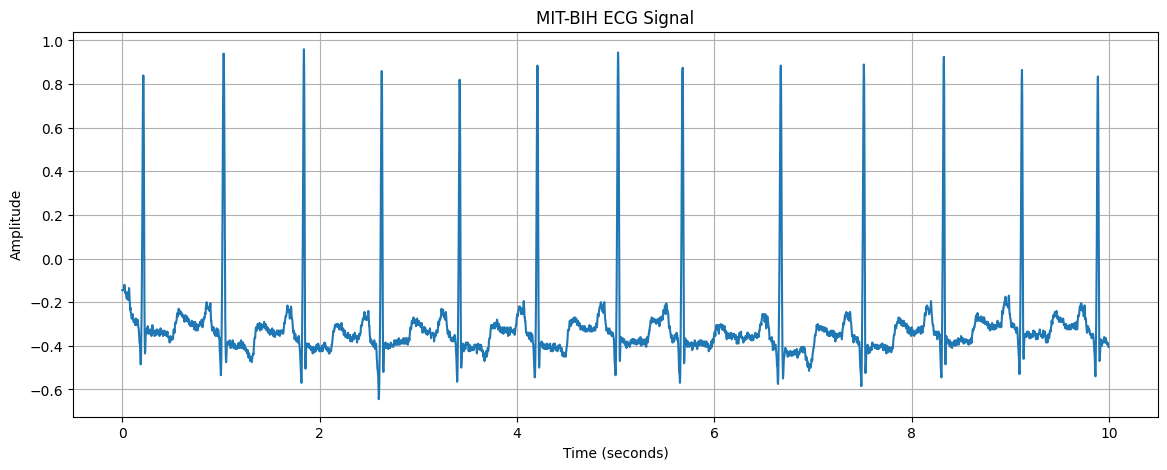

In [50]:
seconds = 10

samples = int(
    seconds * fs
)

time = np.arange(
    samples
) / fs

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    ecg[:samples]
)

plt.title(
    "MIT-BIH ECG Signal"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [51]:
print("Mean:", np.mean(ecg))
print("Standard deviation:", np.std(ecg))
print("Minimum:", np.min(ecg))
print("Maximum:", np.max(ecg))

Mean: -0.3062989769230769
Standard deviation: 0.19319954213721688
Minimum: -2.715
Maximum: 1.435


In [53]:
def bandpass_filter(
    signal,
    lowcut,
    highcut,
    fs,
    order=4
):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        signal
    )


filtered_ecg = bandpass_filter(
    ecg,
    0.5,
    40,
    fs
)

print("Filtering completed")

Filtering completed


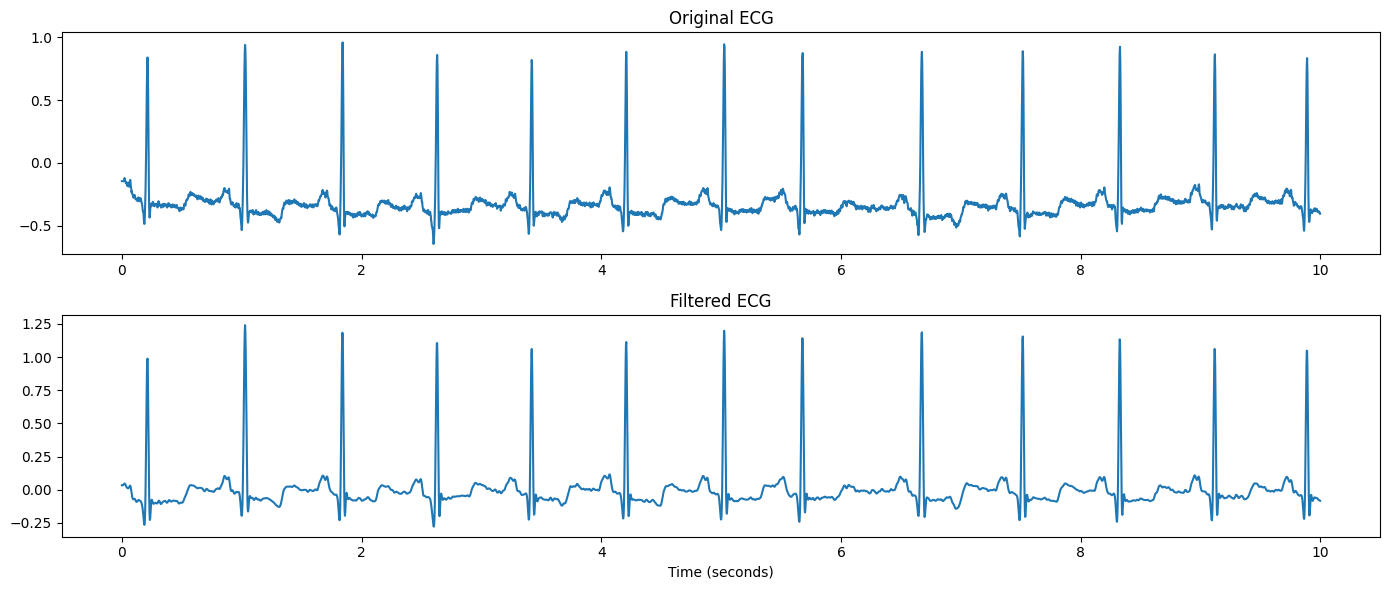

In [54]:
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ecg[:samples]
)

plt.title("Original ECG")


plt.subplot(2, 1, 2)

plt.plot(
    time,
    filtered_ecg[:samples]
)

plt.title("Filtered ECG")

plt.xlabel("Time (seconds)")

plt.tight_layout()

plt.show()

In [55]:
normalized_ecg = (
    filtered_ecg
    -
    np.mean(filtered_ecg)
) / np.std(filtered_ecg)

print(
    "Mean:",
    np.mean(normalized_ecg)
)

print(
    "Standard deviation:",
    np.std(normalized_ecg)
)

Mean: 4.9628677236166995e-18
Standard deviation: 0.9999999999999998


In [56]:
window_seconds = 5

window_size = int(
    window_seconds * fs
)

number_of_windows = (
    len(normalized_ecg)
    // window_size
)

windows = []

for i in range(number_of_windows):

    start = i * window_size
    end = start + window_size

    window = normalized_ecg[
        start:end
    ]

    if len(window) == window_size:
        windows.append(window)

windows = np.array(windows)

print(
    "Windows shape:",
    windows.shape
)

Windows shape: (361, 1800)


In [57]:
signal_features = []

for window in windows:

    features = {
        "Mean": np.mean(window),
        "Std": np.std(window),
        "Minimum": np.min(window),
        "Maximum": np.max(window),
        "Range": np.ptp(window),
        "Energy": np.mean(window ** 2)
    }

    signal_features.append(features)

signal_features_df = pd.DataFrame(
    signal_features
)

display(
    signal_features_df.head()
)

,Mean,Std,Minimum,Maximum,Range,Energy
0,-0.017559,0.872081,-1.522750,6.779481,8.302231,0.760833
1,0.015614,0.932314,-1.324667,6.544627,7.869294,0.869454
2,-0.005751,0.863053,-1.401063,6.384442,7.785506,0.744894
3,-0.010556,0.920245,-1.342908,6.874545,8.217453,0.846963
4,0.000219,0.929163,-1.429475,7.192523,8.621998,0.863344


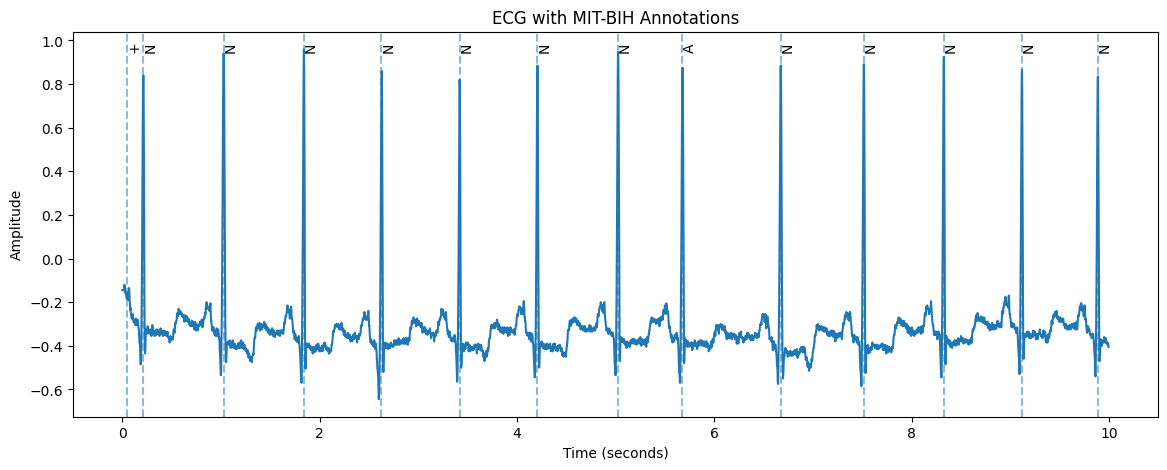

In [58]:
annotation_samples = np.array(
    annotation.sample
)

annotation_symbols = np.array(
    annotation.symbol
)

mask = (
    annotation_samples < samples
)

beat_samples = annotation_samples[
    mask
]

beat_symbols = annotation_symbols[
    mask
]

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    ecg[:samples]
)

for sample, symbol in zip(
    beat_samples,
    beat_symbols
):

    sample_time = sample / fs

    plt.axvline(
        sample_time,
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        sample_time,
        np.max(ecg[:samples]),
        symbol,
        rotation=90
    )

plt.title(
    "ECG with MIT-BIH Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [59]:
summary = pd.DataFrame({

    "Modality": [
        "Tabular",
        "Textual",
        "Image",
        "Signal"
    ],

    "Dataset": [
        "Pima Indians Diabetes",
        "MTSamples",
        "Chest X-Ray Pneumonia",
        "MIT-BIH Arrhythmia"
    ],

    "Cleaning": [
        "Invalid zeros and missing values",
        "URLs, identifiers and stopwords",
        "Resize and normalization",
        "Noise filtering"
    ],

    "Preprocessing": [
        "Imputation and scaling",
        "Tokenization and TF-IDF",
        "Resize and normalization",
        "Filtering and segmentation"
    ],

    "Feature Engineering": [
        "BMI and age groups",
        "TF-IDF",
        "HOG",
        "ECG statistical features"
    ],

    "Analysis": [
        "T-test, Chi-square, ANOVA",
        "EDA and PCA",
        "EDA and visualization",
        "Signal statistics"
    ]

})

display(summary)

,Modality,Dataset,Cleaning,Preprocessing,Feature Engineering,Analysis
0,Tabular,Pima Indians Diabetes,Invalid zeros and missing values,Imputation and scaling,BMI and age groups,"T-test, Chi-square, ANOVA"
1,Textual,MTSamples,"URLs, identifiers and stopwords",Tokenization and TF-IDF,TF-IDF,EDA and PCA
2,Image,Chest X-Ray Pneumonia,Resize and normalization,Resize and normalization,HOG,EDA and visualization
3,Signal,MIT-BIH Arrhythmia,Noise filtering,Filtering and segmentation,ECG statistical features,Signal statistics


In [60]:
print("""
Healthcare Data Considerations

1. Missing values can be represented by valid-looking values.

2. Medical text and images may contain PHI and should be
   anonymized before sharing.

3. Healthcare datasets can have class imbalance.

4. Medical image metadata may contain patient information.

5. ECG signals can contain noise and artifacts.

6. Augmentation should not change clinically meaningful
   information.

7. Feature scaling is useful when variables have different
   ranges.
""")


Healthcare Data Considerations

1. Missing values can be represented by valid-looking values.

2. Medical text and images may contain PHI and should be
   anonymized before sharing.

3. Healthcare datasets can have class imbalance.

4. Medical image metadata may contain patient information.

5. ECG signals can contain noise and artifacts.

6. Augmentation should not change clinically meaningful
   information.

7. Feature scaling is useful when variables have different
   ranges.

